# Xem tất cả file CSV + đánh dấu REP (PEAKDET)

Dùng CHUNG cấu hình với `rep_config.py` và thuật toán của `sim_peakdet.py`
→ số rep TRÙNG KHÍT với simulator. Trục đã chốt: **gy / gy / ay / ay**.

- **§2**: tất cả file, mỗi bài trên trục đã chọn, đánh dấu ▲ peak / ▼ valley / vạch xanh = rep.
- **§3**: xem raw 6 trục 1 file (debug).

> Chạy trong thư mục `training/`.

In [17]:
%matplotlib inline
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# 1 NGUỒN CHÂN LÝ: lấy config + thuật toán từ file simulator
from rep_config import REP_CONFIG, AXES, FS
from sim_peakdet import load_csv_z, count_reps

DATA_DIR = Path('data')

print('Cấu hình (từ rep_config.py):')
for ex, c in REP_CONFIG.items():
    print(f"  {ex:16s} axis={AXES[c['axis']]:3s} delta={c['delta']}  "
          f"min_gap={c['min_gap_ms']}ms  smooth={c['smooth_win']}")

Cấu hình (từ rep_config.py):
  bicep_curl       axis=gy  delta=1.0  min_gap=600ms  smooth=5
  lateral_raise    axis=gy  delta=1.0  min_gap=600ms  smooth=5
  shoulder_press   axis=ay  delta=0.5  min_gap=600ms  smooth=5
  tricep_ext       axis=ay  delta=0.8  min_gap=600ms  smooth=5


## 2. Tất cả file — rep trên trục đã chốt
▲ = đỉnh (peak), ▼ = đáy (valley), vạch xanh = 1 rep được đếm. Xám = z raw, xanh = sau làm mượt.

BICEP_CURL   axis=gy  delta=1.0


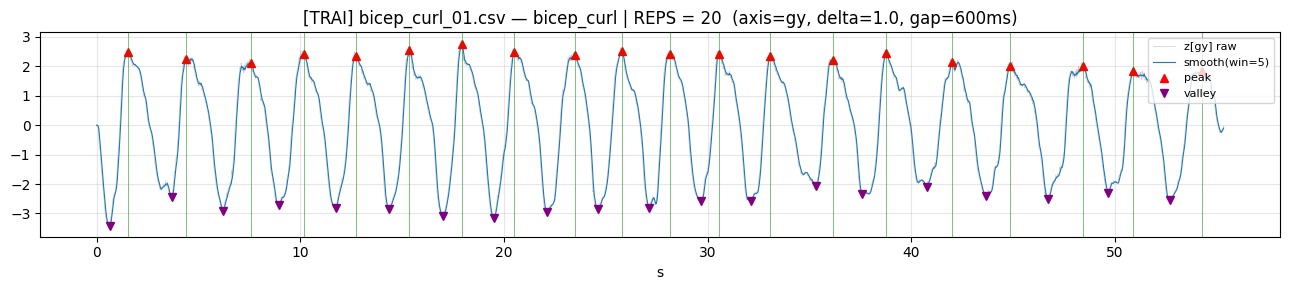

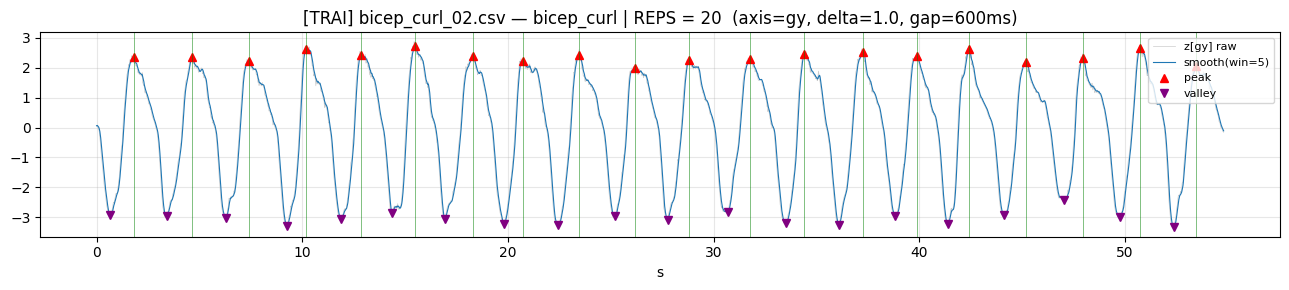

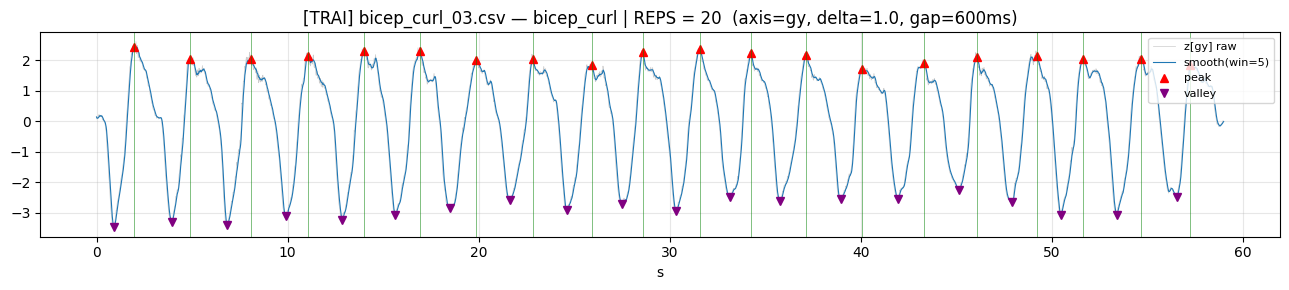

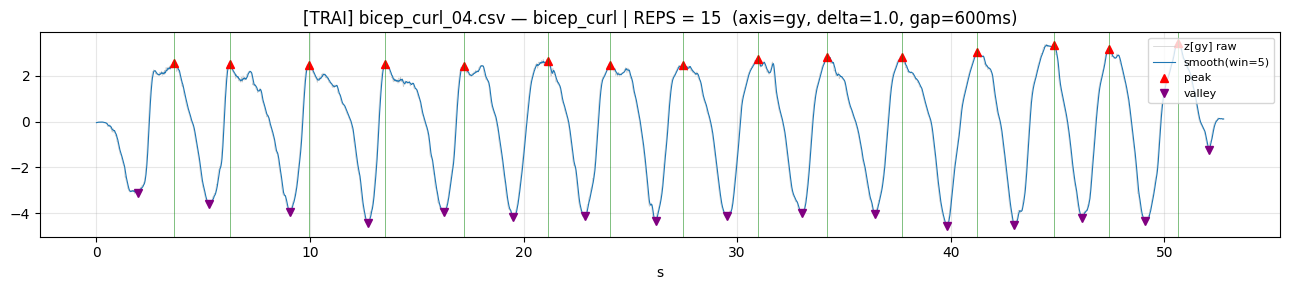

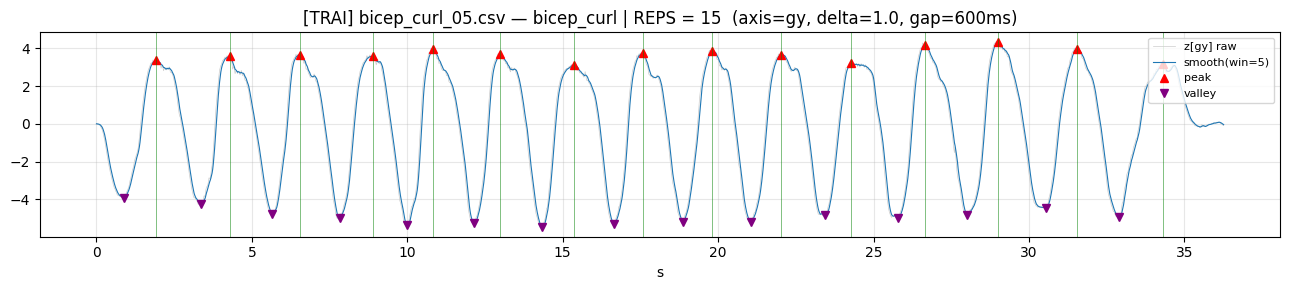

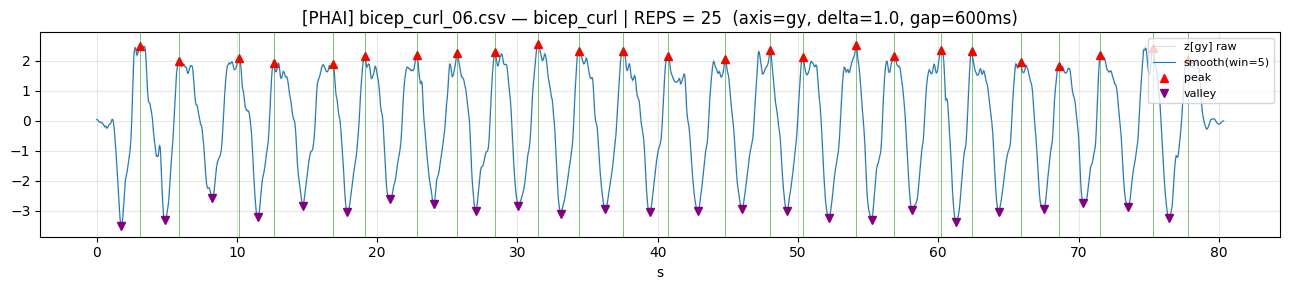

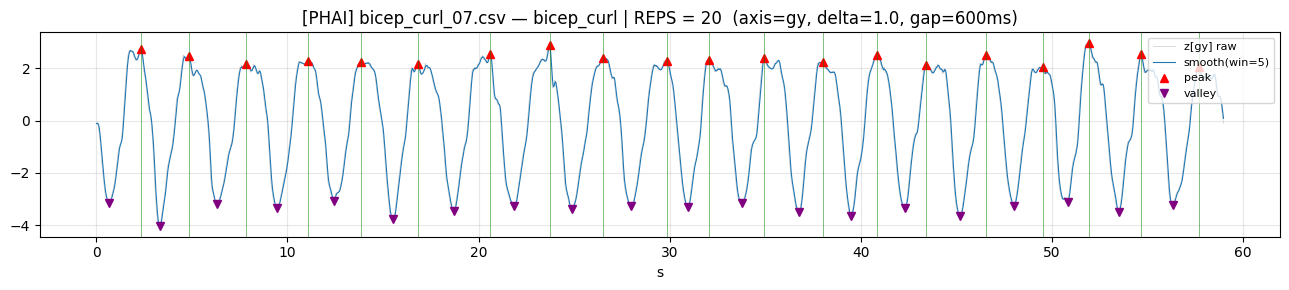

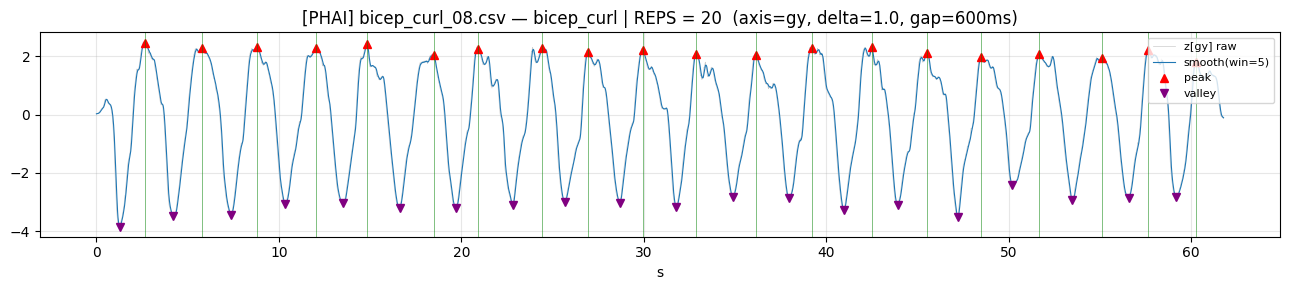

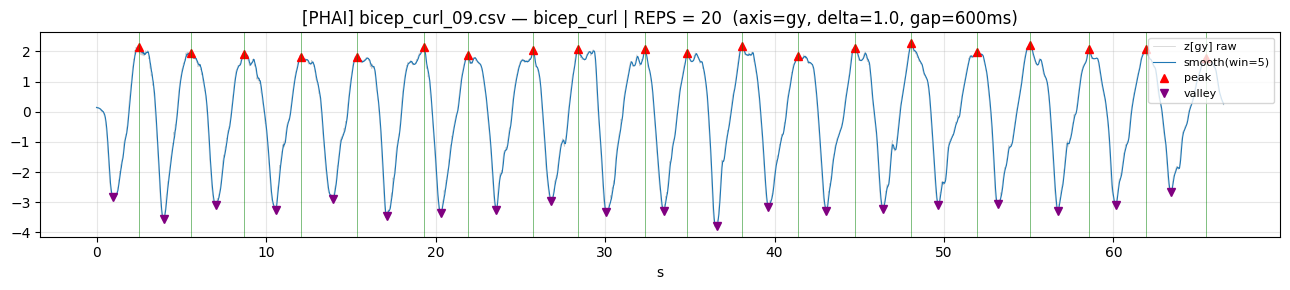

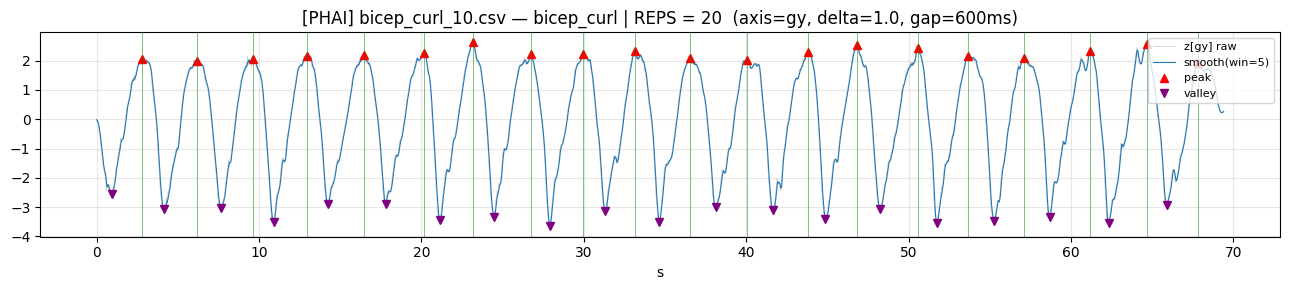

LATERAL_RAISE   axis=gy  delta=1.0


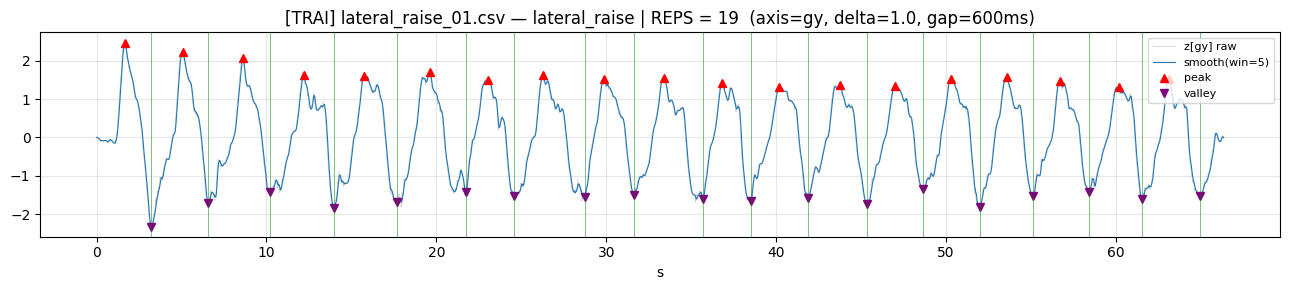

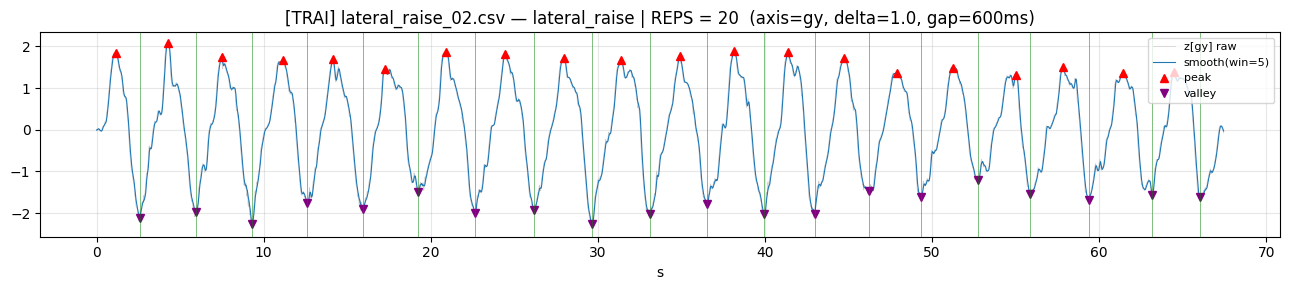

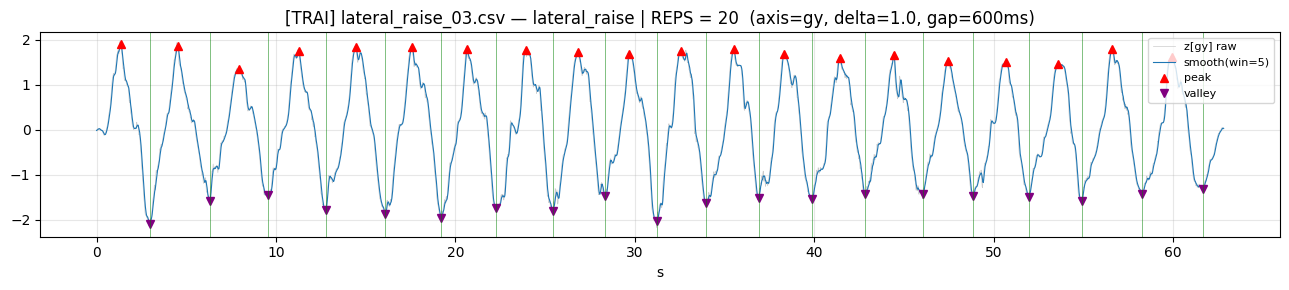

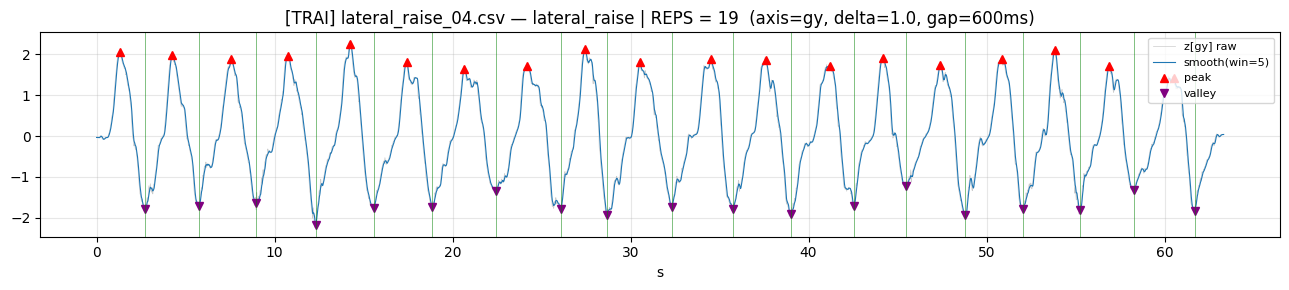

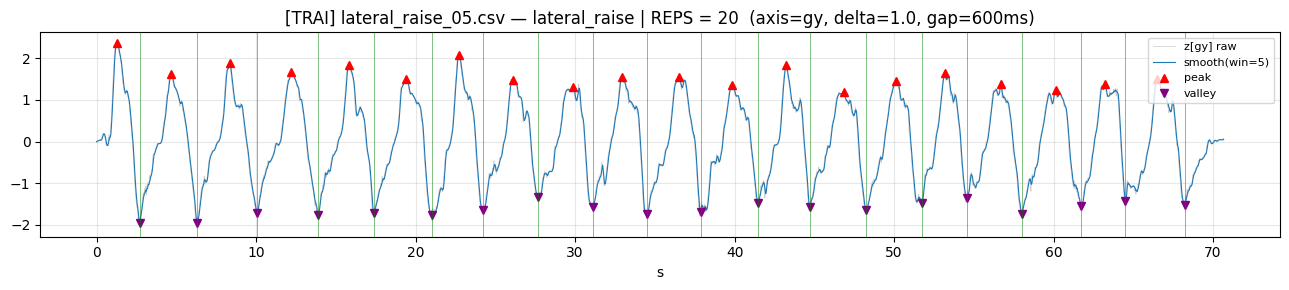

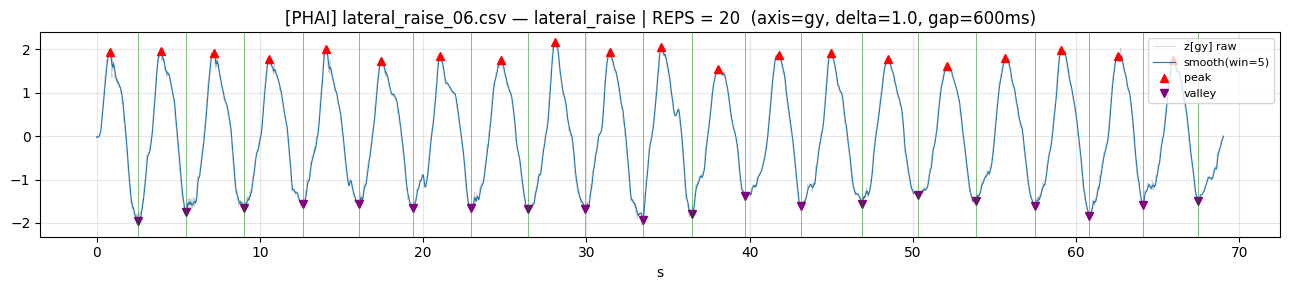

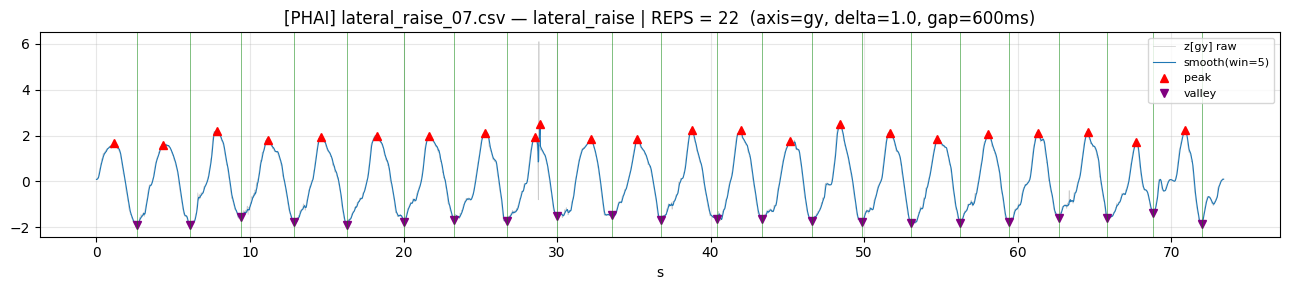

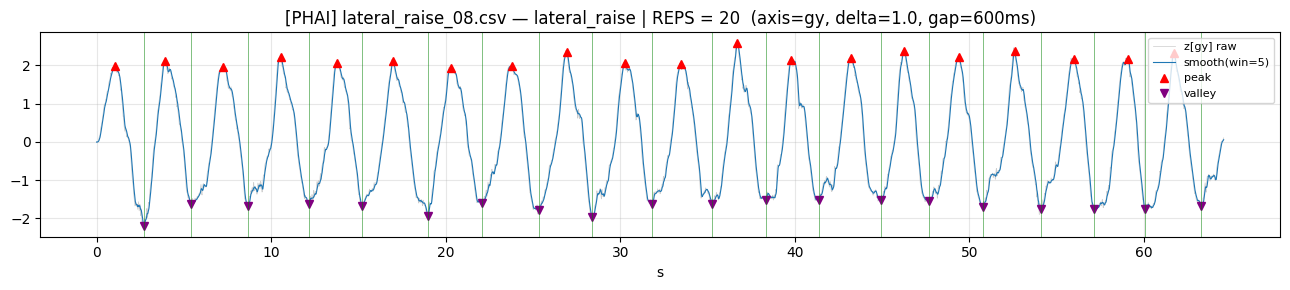

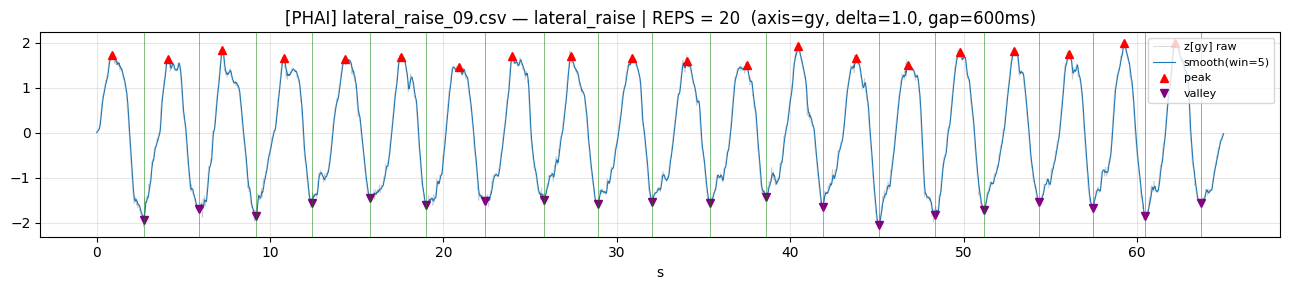

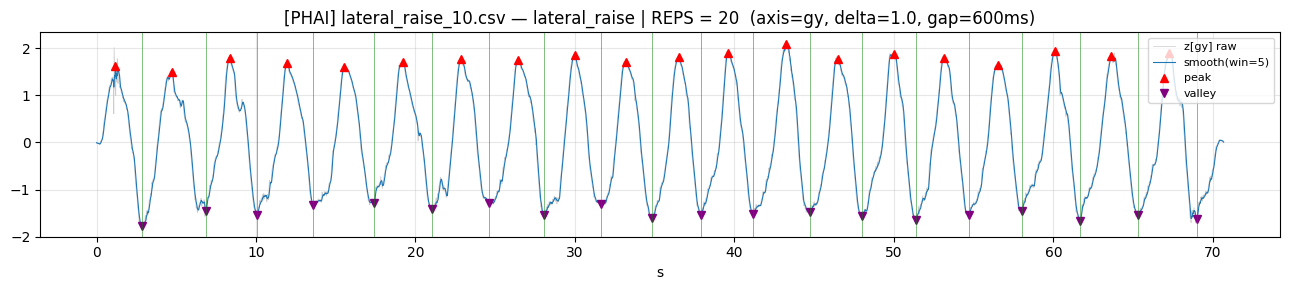

SHOULDER_PRESS   axis=ay  delta=0.5


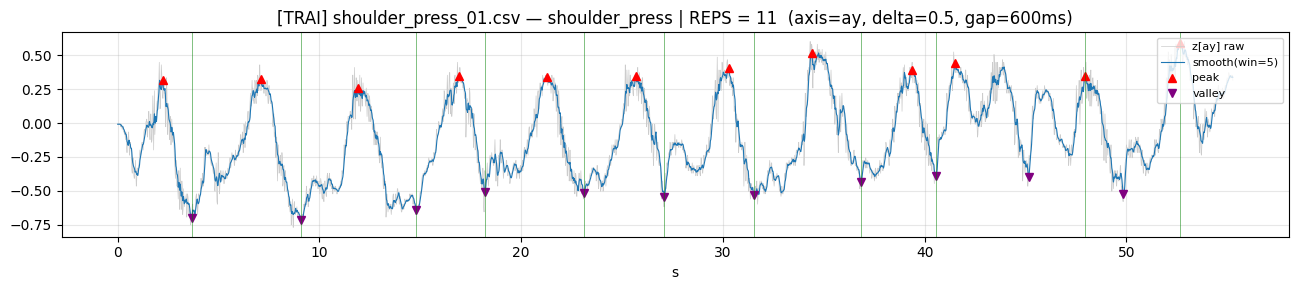

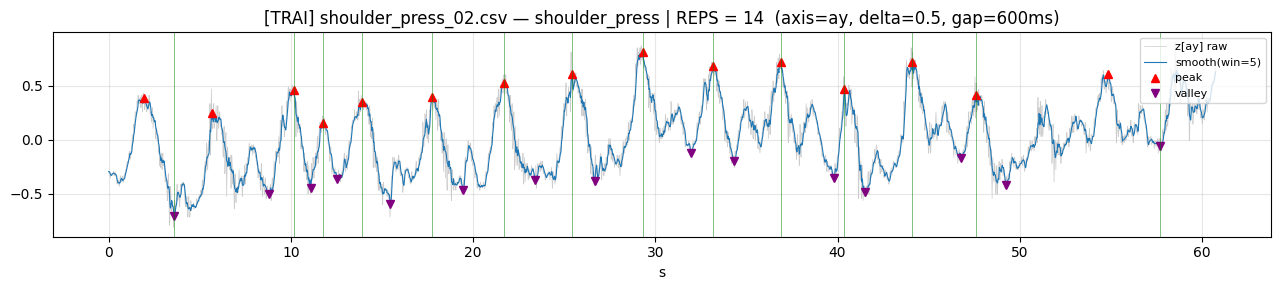

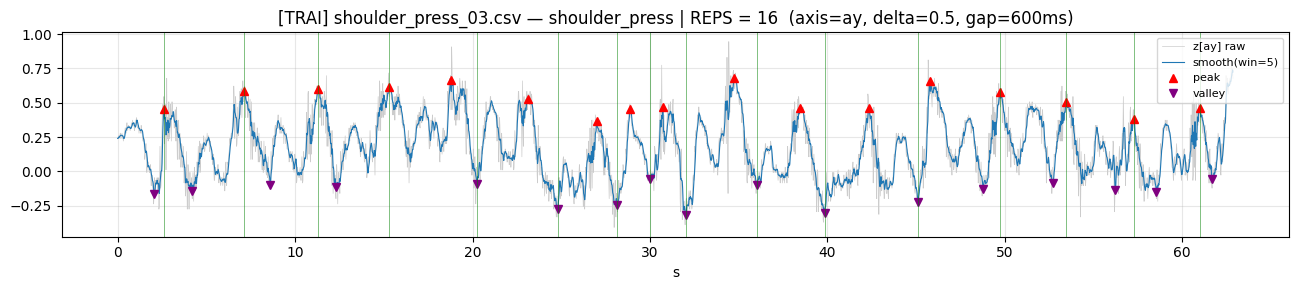

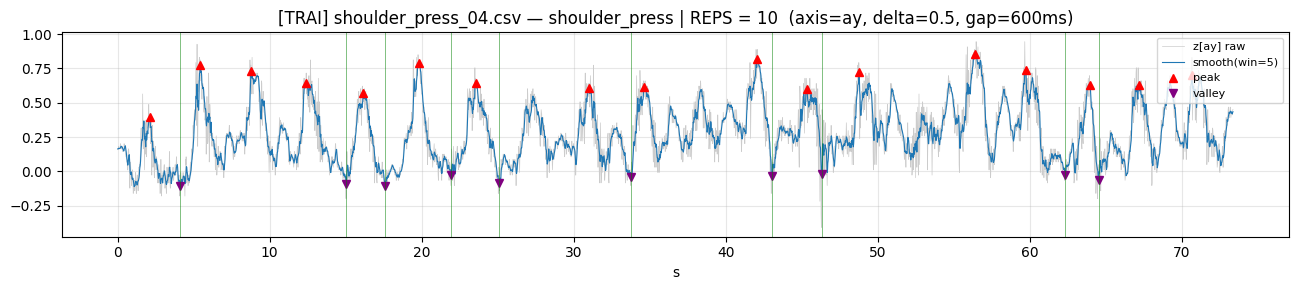

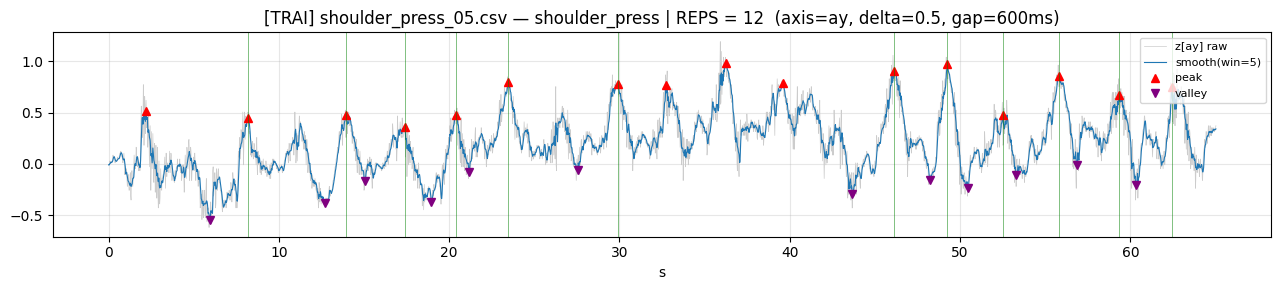

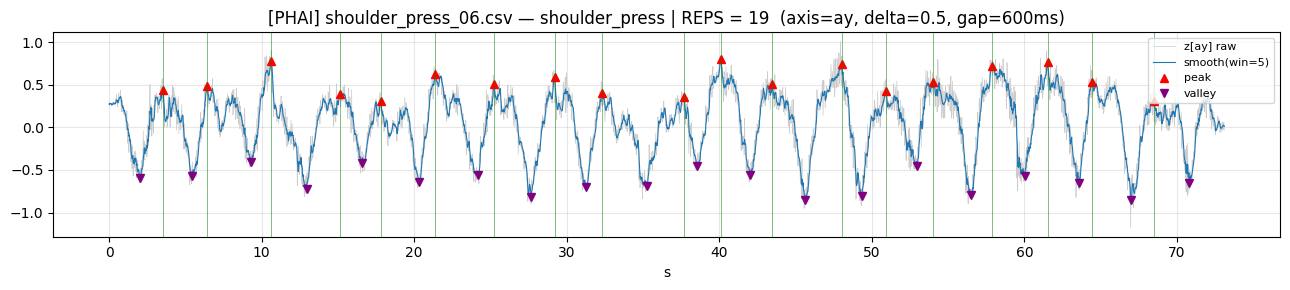

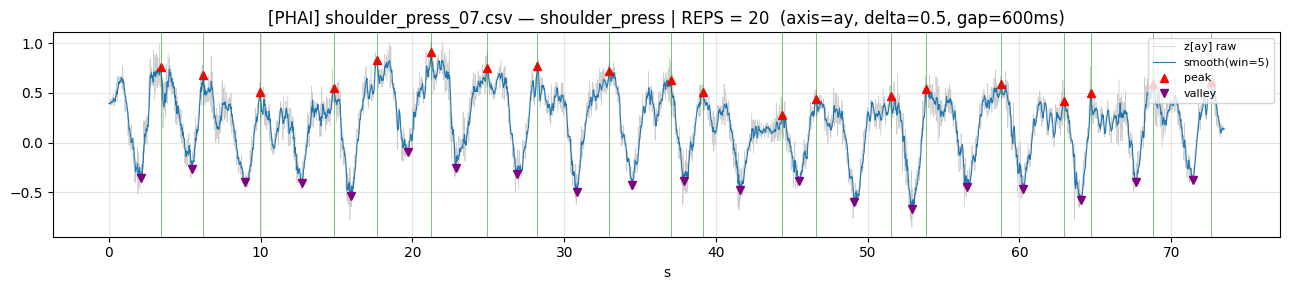

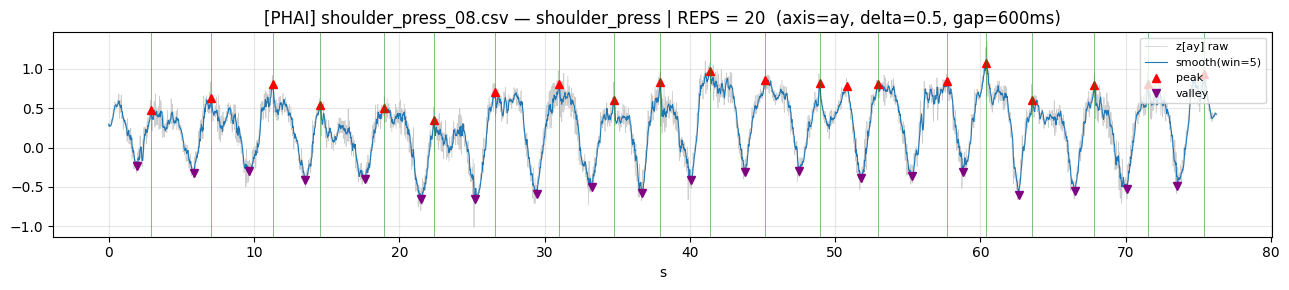

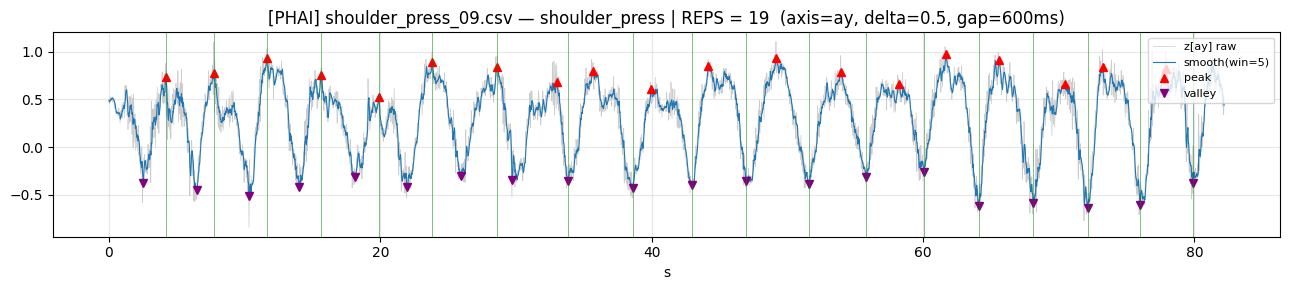

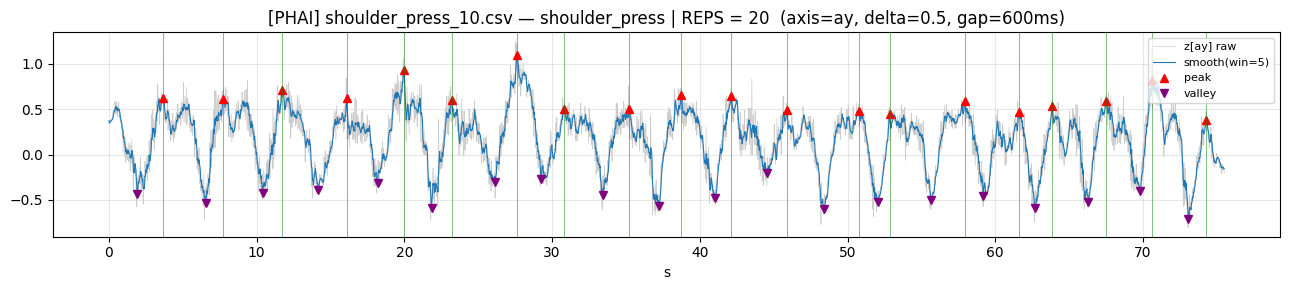

TRICEP_EXT   axis=ay  delta=0.8


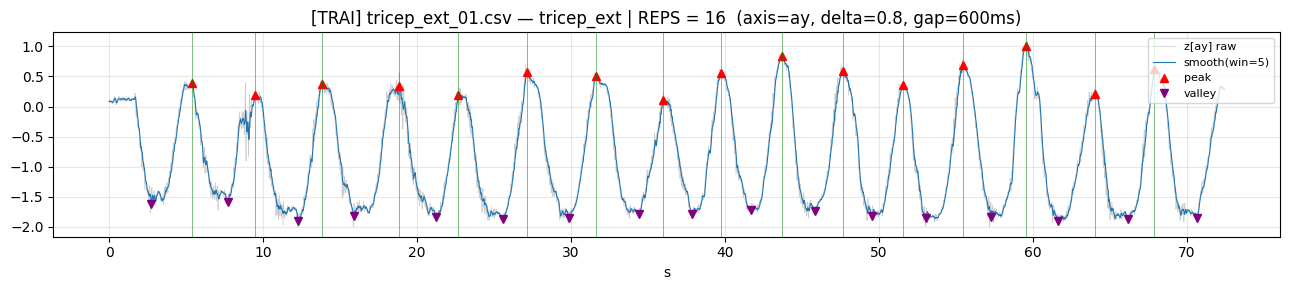

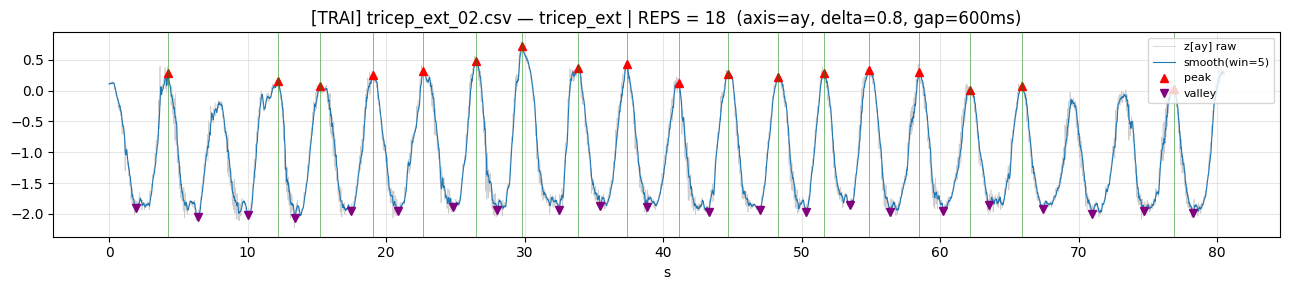

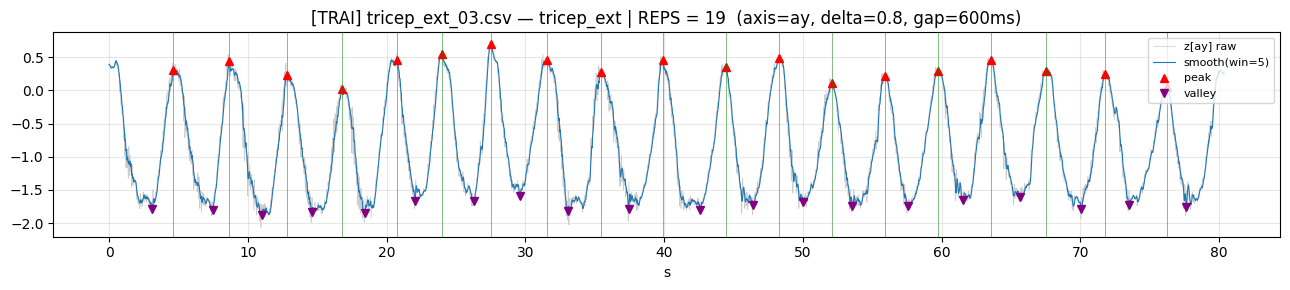

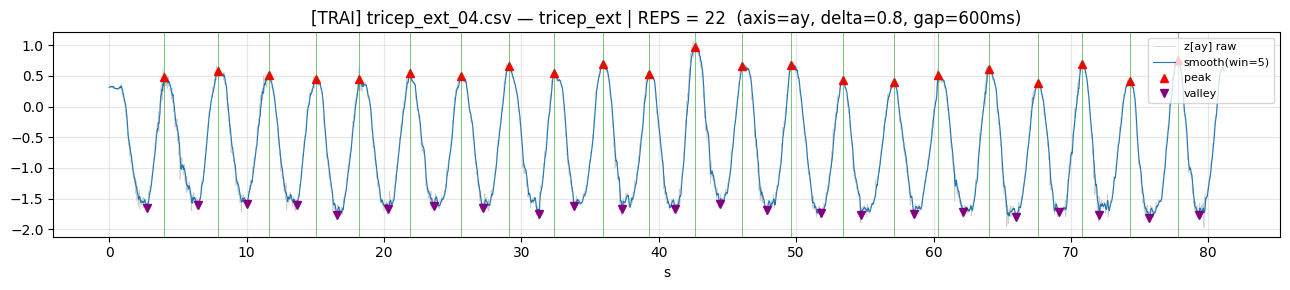

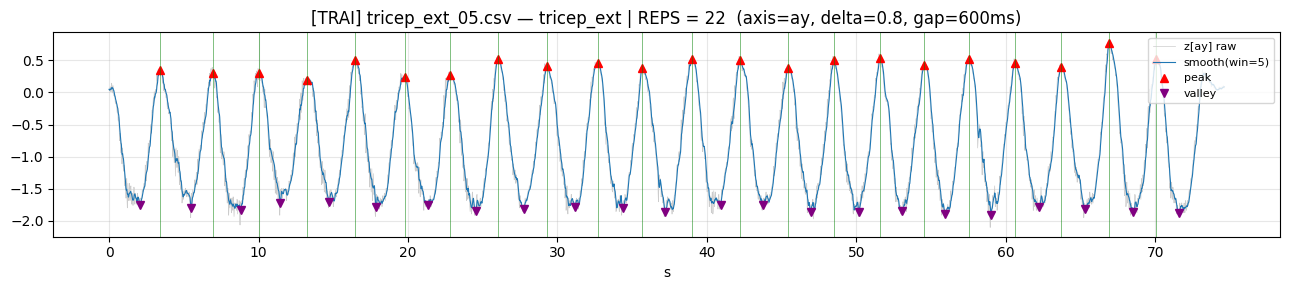

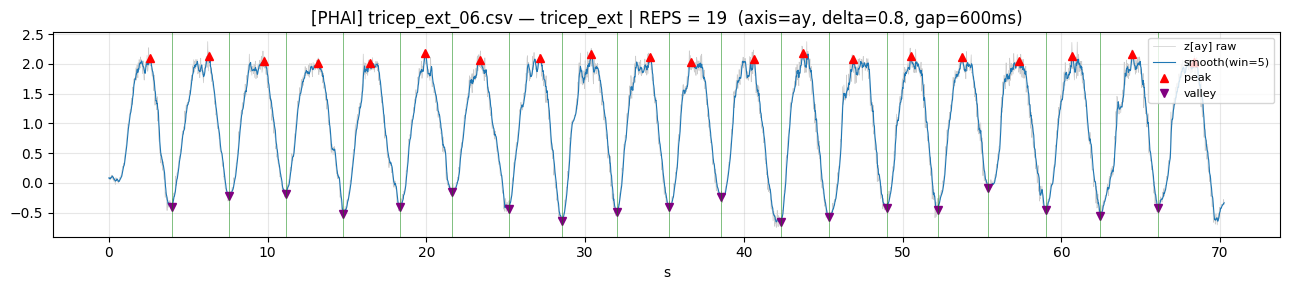

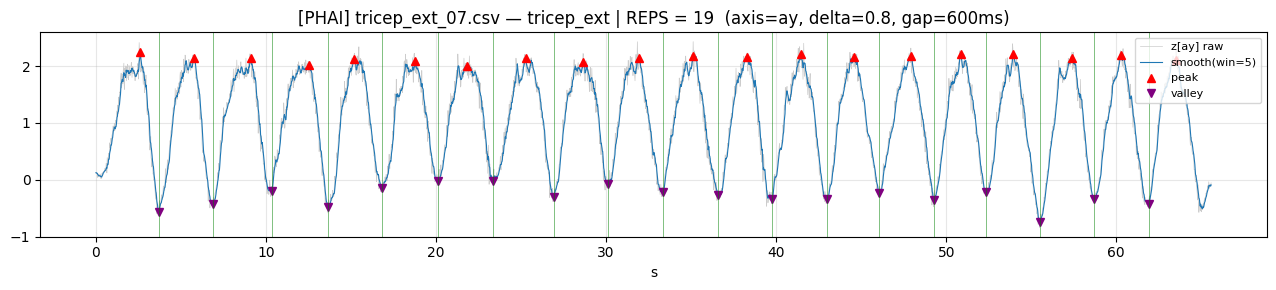

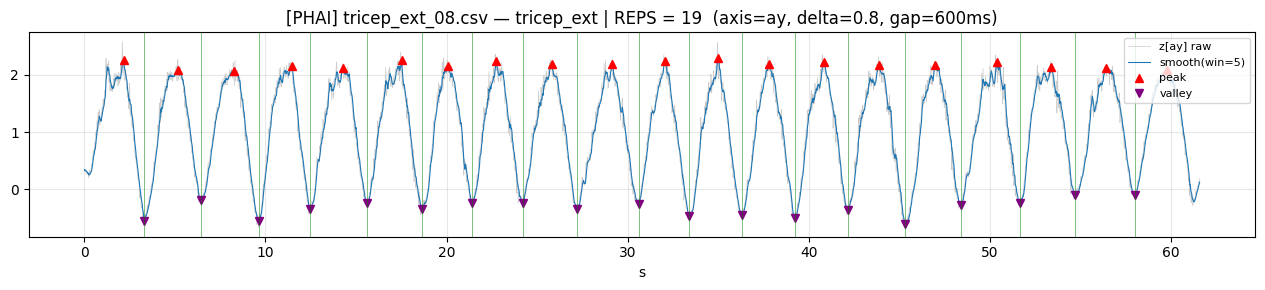

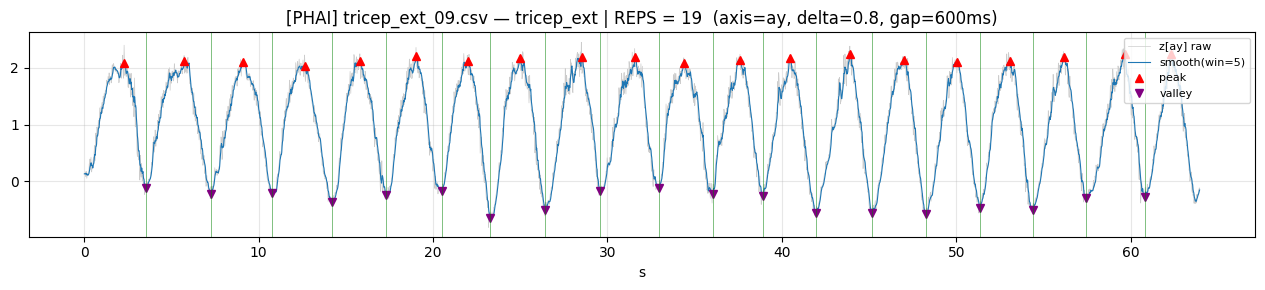

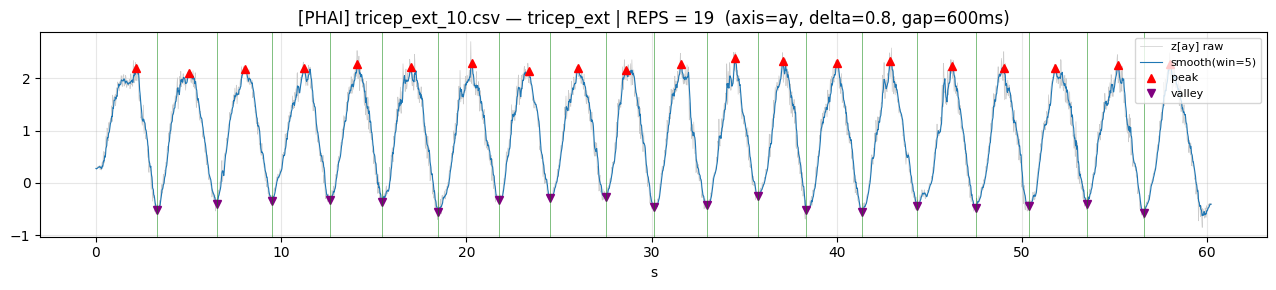

In [18]:
def plot_file(path, ex):
    cfg = REP_CONFIG[ex]
    z = load_csv_z(path)
    reps, marks, sig, events = count_reps(z, cfg)   # GIỐNG HỆT sim_peakdet
    t = np.arange(len(sig)) / FS
    raw = z[:, cfg['axis']]
    pk = [p for ty, p in events if ty > 0]
    vl = [p for ty, p in events if ty < 0]

    fig, ax = plt.subplots(figsize=(13, 3))
    ax.plot(t, raw, lw=0.5, color='#cccccc', label=f"z[{AXES[cfg['axis']]}] raw")
    ax.plot(t, sig, lw=0.8, color='#1f77b4', label=f"smooth(win={cfg['smooth_win']})")
    if pk:
        pk = np.asarray(pk); ax.plot(pk / FS, sig[pk], '^', color='red', ms=6, label='peak')
    if vl:
        vl = np.asarray(vl); ax.plot(vl / FS, sig[vl], 'v', color='purple', ms=6, label='valley')
    for m in marks:
        ax.axvline(m / FS, color='green', lw=0.7, alpha=0.5)
    try:
        grp = 'TRAI' if int(path.stem.split('_')[-1]) <= 5 else 'PHAI'
    except ValueError:
        grp = '?'
    ax.set_title(f"[{grp}] {path.name} — {ex} | REPS = {reps}  "
                 f"(axis={AXES[cfg['axis']]}, delta={cfg['delta']}, gap={cfg['min_gap_ms']}ms)")
    ax.set_xlabel('s'); ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)
    fig.tight_layout(); plt.show()


chon_bai = None   # None = cả 4 bài ; hoặc vd 'shoulder_press'
for ex in ([chon_bai] if chon_bai else list(REP_CONFIG.keys())):
    cfg = REP_CONFIG[ex]
    print('=' * 80)
    print(f"{ex.upper()}   axis={AXES[cfg['axis']]}  delta={cfg['delta']}")
    print('=' * 80)
    for f in sorted((DATA_DIR / ex).glob('*.csv')):
        plot_file(f, ex)

## 3. Soi 1 file — raw 6 trục (debug chọn trục)

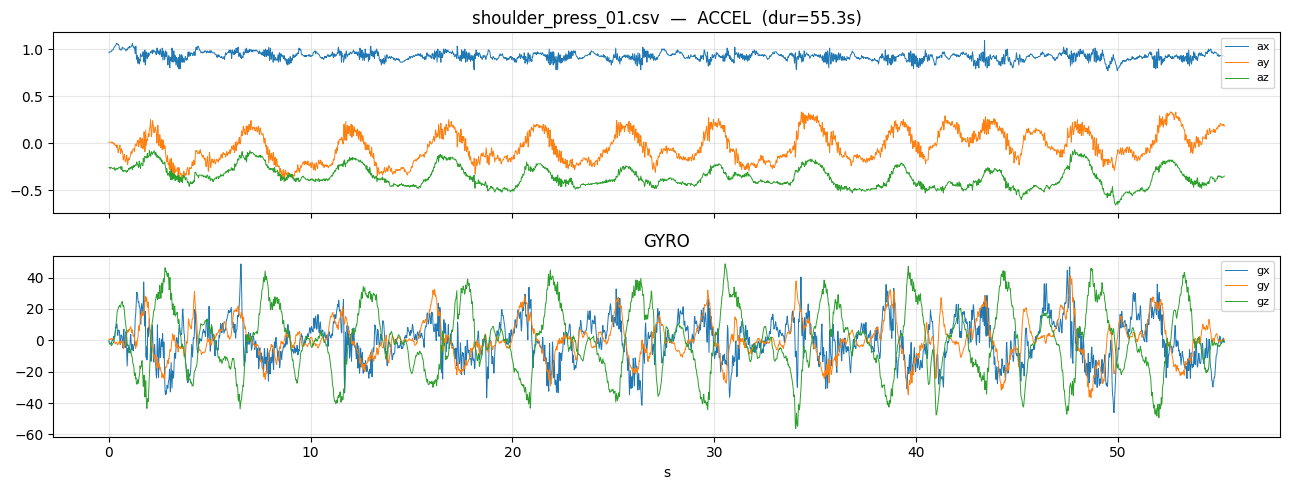

In [19]:
def plot_raw(path):
    d = pd.read_csv(path)[AXES].values.astype(float)
    t = np.arange(len(d)) / FS
    fig, ax = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
    for j, name in zip([0, 1, 2], ['ax', 'ay', 'az']):
        ax[0].plot(t, d[:, j], lw=0.7, label=name)
    ax[0].set_title(f'{path.name}  —  ACCEL  (dur={len(d)/FS:.1f}s)')
    ax[0].legend(loc='upper right', fontsize=8); ax[0].grid(alpha=0.3)
    for j, name in zip([3, 4, 5], ['gx', 'gy', 'gz']):
        ax[1].plot(t, d[:, j], lw=0.7, label=name)
    ax[1].set_title('GYRO'); ax[1].legend(loc='upper right', fontsize=8)
    ax[1].grid(alpha=0.3); ax[1].set_xlabel('s')
    fig.tight_layout(); plt.show()

plot_raw(DATA_DIR / 'shoulder_press' / 'shoulder_press_01.csv')